(np)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`NumPy <single: NumPy>`

```{index} single: Python; NumPy
```

```{epigraph}
"Let's be clear: the work of science has nothing whatever to do with consensus.  Consensus is the business of politics. Science, on the contrary, requires only one investigator who happens to be right, which means that he or she has results that are verifiable by reference to the real world. In science consensus is irrelevant. What is relevant is reproducible results." -- Michael Crichton
```

Anaconda-യിലുള്ളതിന് പുറമെ, ഈ lecture-ന് താഴെപ്പറയുന്ന libraries ആവശ്യമാണ്:

In [1]:
!pip install quantecon

## Overview

[NumPy](https://en.wikipedia.org/wiki/NumPy) numerical programming-നുള്ള ഒരു first-rate library ആണ്

* academia, finance-ഉം industry-യിലും വ്യാപകമായി ഉപയോഗിക്കപ്പെടുന്നു.
* Mature, fast, stable-ഉം continuous development-ൽ ഉള്ളതും.

മുൻ lectures-ൽ NumPy ഉൾപ്പെടുന്ന കുറച്ച് code നാം ഇതിനകം കണ്ടിട്ടുണ്ട്.

ഈ lecture-ൽ, നാം ഇവയെക്കുറിച്ച് കൂടുതൽ systematic ആയ ഒരു discussion ആരംഭിക്കും:

1. NumPy arrays-ഉം
1. NumPy നൽകുന്ന fundamental array processing operations-ഉം.


(ഒരു alternative reference-ന്, [the official NumPy documentation](https://numpy.org/doc/stable/reference/) കാണുക.)

നാം താഴെപ്പറയുന്ന imports ഉപയോഗിക്കും.

In [2]:
import numpy as np
import random
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

(numpy_array)=
## NumPy Arrays

```{index} single: NumPy; Arrays
```

NumPy പരിഹരിക്കുന്ന essential problem, fast array processing ആണ്.

NumPy define ചെയ്യുന്ന ഏറ്റവും പ്രധാനപ്പെട്ട structure ഒരു array data type ആണ്, ഔപചാരികമായി
[numpy.ndarray](https://numpy.org/doc/stable/reference/arrays.ndarray.html) എന്നറിയപ്പെടുന്നു.

NumPy arrays scientific Python ecosystem-ന്റെ വളരെ വലിയൊരു ഭാഗത്തിന് ശക്തി പകരുന്നു.

### Basics

zeros മാത്രം അടങ്ങിയ ഒരു NumPy array create ചെയ്യാൻ നാം [np.zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html#numpy.zeros) ഉപയോഗിക്കുന്നു

In [3]:
a = np.zeros(3)
a

array([0., 0., 0.])

In [4]:
type(a)

numpy.ndarray

NumPy arrays native Python lists-നോട് ഒരു തരത്തിൽ സാമ്യമുള്ളതാണ്, ഒഴികെ

* Data *homogeneous ആയിരിക്കണം* (എല്ലാ elements-ഉം ഒരേ type-ലുള്ളവ).
* ഈ types NumPy നൽകുന്ന [data types](https://numpy.org/doc/stable/reference/arrays.dtypes.html) (`dtypes`)-ൽ ഒന്നായിരിക്കണം.

ഈ dtypes-ൽ ഏറ്റവും പ്രധാനപ്പെട്ടവ:

* float64: 64 bit floating-point number
* int64: 64 bit integer
* bool:  8 bit True or False

complex numbers, unsigned integers മുതലായവ represent ചെയ്യാൻ dtypes-ഉം ഉണ്ട്.

modern machines-ൽ, arrays-ക്കുള്ള default dtype `float64` ആണ്

In [5]:
a = np.zeros(3)
type(a[0])

numpy.float64

integers ഉപയോഗിക്കണമെങ്കിൽ താഴെപ്പറയുന്ന വിധം specify ചെയ്യാം:

In [6]:
a = np.zeros(3, dtype=int)
type(a[0])

numpy.int64

(numpy_shape_dim)=
### Shape and Dimension

```{index} single: NumPy; Arrays (Shape and Dimension)
```

താഴെപ്പറയുന്ന assignment പരിഗണിക്കുക

In [7]:
z = np.zeros(10)

ഇവിടെ `z` ഒരു **flat** array ആണ് --- row-യും column vector-ഉം അല്ല.

In [8]:
z.shape

(10,)

ഇവിടെ shape tuple-ന് ഒരു element മാത്രമേ ഉള്ളൂ, അത് array-യുടെ length ആണ്
(ഒരു element ഉള്ള tuples ഒരു comma-യിൽ അവസാനിക്കും).

ഇതിന് ഒരു additional dimension നൽകാൻ, നമുക്ക് `shape` attribute change ചെയ്യാം

In [9]:
z.shape = (10, 1)   # Convert flat array to column vector (two-dimensional)
z

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [10]:
z = np.zeros(4)     # Flat array
z.shape = (2, 2)    # Two-dimensional array
z

array([[0., 0.],
       [0., 0.]])

അവസാന case-ൽ, 2x2 array ഉണ്ടാക്കാൻ, `zeros()` function-ന് ഒരു tuple pass ചെയ്യാനും കഴിയും,
`z = np.zeros((2, 2))` എന്നപോലെ.



(creating_arrays)=
### Creating Arrays

```{index} single: NumPy; Arrays (Creating)
```

നാം കണ്ടതുപോലെ, `np.zeros` function zeros-ന്റെ ഒരു array create ചെയ്യുന്നു.

`np.ones` എന്താണ് create ചെയ്യുന്നതെന്ന് നിങ്ങൾക്ക് ഊഹിക്കാൻ കഴിയും.

ബന്ധപ്പെട്ട ഒന്നാണ് `np.empty`, ഇത് memory-യിൽ arrays create ചെയ്യുന്നു, പിന്നീട് data ഉപയോഗിച്ച് populate ചെയ്യാവുന്നത്

In [11]:
z = np.empty(3)
z

array([0., 0., 0.])

ഇവിടെ കാണുന്ന numbers garbage values ആണ്.

(Python 3 contiguous 64 bit memory pieces allocate ചെയ്യുന്നു, ആ memory slots-ന്റെ existing contents `float64` values ആയി interpret ചെയ്യപ്പെടുന്നു)

evenly spaced numbers-ന്റെ ഒരു grid set up ചെയ്യാൻ `np.linspace` ഉപയോഗിക്കുക

In [12]:
z = np.linspace(2, 4, 5)  # From 2 to 4, with 5 elements

ഒരു identity matrix create ചെയ്യാൻ `np.identity` അല്ലെങ്കിൽ `np.eye` ഉപയോഗിക്കുക

In [13]:
z = np.identity(2)
z

array([[1., 0.],
       [0., 1.]])

കൂടാതെ, `np.array` ഉപയോഗിച്ച് Python lists, tuples മുതലായവയിൽ നിന്ന് NumPy arrays create ചെയ്യാം

In [14]:
z = np.array([10, 20])                 # ndarray from Python list
z

array([10, 20])

In [15]:
type(z)

numpy.ndarray

In [16]:
z = np.array((10, 20), dtype=float)    # Here 'float' is equivalent to 'np.float64'
z

array([10., 20.])

In [17]:
z = np.array([[1, 2], [3, 4]])         # 2D array from a list of lists
z

array([[1, 2],
       [3, 4]])

`np.asarray` കൂടി കാണുക, ഇത് സമാനമായ ഒരു function ചെയ്യുന്നു, പക്ഷേ ഇതിനകം ഒരു NumPy array-ൽ ഉള്ള data-യുടെ
distinct copy ഉണ്ടാക്കുന്നില്ല.

numeric data അടങ്ങിയ ഒരു text file-ൽ നിന്ന് array data read ചെയ്യാൻ `np.loadtxt` ഉപയോഗിക്കുക ---വിശദാംശങ്ങൾക്ക് [the documentation](https://numpy.org/doc/stable/reference/routines.io.html) കാണുക.



### Array Indexing

```{index} single: NumPy; Arrays (Indexing)
```

ഒരു flat array-ക്ക്, indexing Python sequences-ന് സമാനമാണ്:

In [18]:
z = np.linspace(1, 2, 5)
z

array([1.  , 1.25, 1.5 , 1.75, 2.  ])

In [19]:
z[0]

np.float64(1.0)

In [20]:
z[0:2]  # Two elements, starting at element 0

array([1.  , 1.25])

In [21]:
z[-1]

np.float64(2.0)

2D arrays-ന്, index syntax താഴെപ്പറയുന്നത് ആണ്:

In [22]:
z = np.array([[1, 2], [3, 4]])
z

array([[1, 2],
       [3, 4]])

In [23]:
z[0, 0]

np.int64(1)

In [24]:
z[0, 1]

np.int64(2)

ഇങ്ങനെ.

Columns-ഉം rows-ഉം താഴെപ്പറയുന്ന വിധം extract ചെയ്യാം

In [25]:
z[0, :]

array([1, 2])

In [26]:
z[:, 1]

array([2, 4])

elements extract ചെയ്യാൻ integers-ന്റെ NumPy arrays-ഉം ഉപയോഗിക്കാം

In [27]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [28]:
indices = np.array((0, 2, 3))
z[indices]

array([2. , 3. , 3.5])

അവസാനമായി, `dtype bool`-ന്റെ ഒരു array elements extract ചെയ്യാൻ ഉപയോഗിക്കാം

In [29]:
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [30]:
d = np.array([0, 1, 1, 0, 0], dtype=bool)
d

array([False,  True,  True, False, False])

In [31]:
z[d]

array([2.5, 3. ])

താഴെ ഇത് എന്തുകൊണ്ട് ഉപകാരപ്രദമാണെന്ന് നാം കാണും.

ഒരു aside: slice notation ഉപയോഗിച്ച് ഒരു array-യുടെ എല്ലാ elements-ഉം ഒരു number-ന് equal ആയി set ചെയ്യാം

In [32]:
z = np.empty(3)
z

array([2. , 3. , 3.5])

In [33]:
z[:] = 42
z

array([42., 42., 42.])

### Array Methods

```{index} single: NumPy; Arrays (Methods)
```

Arrays-ന് ഉപകാരപ്രദമായ methods ഉണ്ട്, അവയെല്ലാം carefully optimize ചെയ്യപ്പെട്ടതാണ്

In [34]:
a = np.array((4, 3, 2, 1))
a

array([4, 3, 2, 1])

In [35]:
a.sort()              # Sorts a in place
a

array([1, 2, 3, 4])

In [36]:
a.sum()               # Sum

np.int64(10)

In [37]:
a.mean()              # Mean

np.float64(2.5)

In [38]:
a.max()               # Max

np.int64(4)

In [39]:
a.argmax()            # Returns the index of the maximal element

np.int64(3)

In [40]:
a.cumsum()            # Cumulative sum of the elements of a

array([ 1,  3,  6, 10])

In [41]:
a.cumprod()           # Cumulative product of the elements of a

array([ 1,  2,  6, 24])

In [42]:
a.var()               # Variance

np.float64(1.25)

In [43]:
a.std()               # Standard deviation

np.float64(1.118033988749895)

In [44]:
a.shape = (2, 2)
a.T                   # Equivalent to a.transpose()

array([[1, 3],
       [2, 4]])

അറിഞ്ഞിരിക്കേണ്ട മറ്റൊരു method `searchsorted()` ആണ്.

`z` ഒരു nondecreasing array ആണെങ്കിൽ, `z.searchsorted(a)`, `z`-ന്റെ `>= a` ആയ ആദ്യത്തെ
element-ന്റെ index return ചെയ്യുന്നു

In [45]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [46]:
z.searchsorted(2.2)

np.int64(1)

## Arithmetic Operations

```{index} single: NumPy; Arithmetic Operations
```

`+`, `-`, `*`, `/`, `**` എന്നീ operators എല്ലാം arrays-ൽ *elementwise* ആയി act ചെയ്യുന്നു

In [47]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
a + b

array([ 6,  8, 10, 12])

In [48]:
a * b

array([ 5, 12, 21, 32])

താഴെപ്പറയുന്ന വിധം ഓരോ element-ലേക്കും ഒരു scalar add ചെയ്യാം

In [49]:
a + 10

array([11, 12, 13, 14])

Scalar multiplication സമാനമാണ്

In [50]:
a * 10

array([10, 20, 30, 40])

two-dimensional arrays-ഉം ഇതേ general rules follow ചെയ്യുന്നു

In [51]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A + B

array([[2., 2.],
       [2., 2.]])

In [52]:
A + 10

array([[11., 11.],
       [11., 11.]])

In [53]:
A * B

array([[1., 1.],
       [1., 1.]])

(numpy_matrix_multiplication)=
പ്രത്യേകിച്ച്, `A * B` matrix product *അല്ല*, ഇത് ഒരു element-wise product ആണ്.


## Matrix Multiplication

```{index} single: NumPy; Matrix Multiplication
```

```{index} single: NumPy; Matrix Multiplication
```

matrix multiplication-ന് നാം `@` symbol ഉപയോഗിക്കുന്നു, താഴെപ്പറയുന്ന വിധം:

In [54]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A @ B

array([[2., 2.],
       [2., 2.]])

flat arrays-ൽ ഈ syntax പ്രവർത്തിക്കുന്നു --- നിങ്ങൾക്ക് എന്താണ് വേണ്ടതെന്ന് NumPy ഒരു educated guess
ഉണ്ടാക്കുന്നു:

In [55]:
A @ (0, 1)

array([1., 1.])

നാം post-multiplying ചെയ്യുന്നതിനാൽ, tuple ഒരു column vector ആയി treat ചെയ്യപ്പെടുന്നു.



(broadcasting)=
## Broadcasting

```{index} single: NumPy; Broadcasting
```

(ഈ section, [Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html) നൽകിയ broadcasting-നെക്കുറിച്ചുള്ള excellent discussion extend ചെയ്യുന്നു.)

```{note}
Broadcasting, NumPy-യുടെ ഒരു വളരെ പ്രധാനപ്പെട്ട aspect ആണ്. അതേസമയം, advanced broadcasting താരതമ്യേന complex ആണ്, താഴെയുള്ള ചില details ആദ്യ pass-ൽ skim ചെയ്യാവുന്നതാണ്.
```

element-wise operations-ൽ, arrays-ന് ഒരേ shape ഉണ്ടായിരിക്കണമെന്നില്ല.

ഇത് സംഭവിക്കുമ്പോൾ, സാധ്യമാകുമ്പോഴൊക്കെ NumPy automatic ആയി arrays-നെ ഒരേ shape-ലേക്ക് expand ചെയ്യും.

NumPy-യിലെ ഈ ഉപകാരപ്രദമായ (എന്നാൽ ചിലപ്പോൾ confusing) feature-നെ **broadcasting** എന്ന് വിളിക്കുന്നു.

Broadcasting-ന്റെ value എന്തെന്നാൽ

* `for` loops ഒഴിവാക്കാം, ഇത് numerical code fast ആയി run ചെയ്യാൻ സഹായിക്കുന്നു, കൂടാതെ
* broadcasting, arrays-ന്റെ dimensions memory-യിൽ actually create ചെയ്യാതെ operations implement ചെയ്യാൻ നമ്മെ അനുവദിക്കുന്നു, arrays വലുതായിരിക്കുമ്പോൾ ഇത് പ്രധാനമാണ്.

ഉദാഹരണത്തിന്, `a` ഒരു $3 \times 3$ array (`a -> (3, 3)`) ആണെന്ന് കരുതുക, `b` മൂന്ന് elements ഉള്ള ഒരു flat array (`b -> (3,)`) ആണെന്നും.

ഇവ ഒരുമിച്ച് add ചെയ്യുമ്പോൾ, NumPy automatic ആയി `b -> (3,)`, `b -> (3, 3)` ആയി expand ചെയ്യും.

element-wise addition ഒരു $3 \times 3$ array-ൽ result ചെയ്യും

In [56]:
a = np.array(
        [[1, 2, 3], 
         [4, 5, 6], 
         [7, 8, 9]])
b = np.array([3, 6, 9])

a + b

array([[ 4,  8, 12],
       [ 7, 11, 15],
       [10, 14, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation ഇതാ:

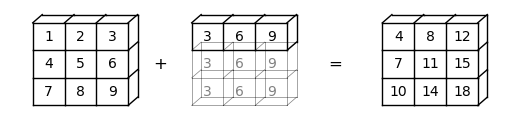

In [57]:
# Adapted and modified based on the code in the book written by Jake VanderPlas (see https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Broadcasting)
# Originally from astroML: see https://www.astroml.org/book_figures/appendix/fig_broadcast_visual.html


def draw_cube(ax, xy, size, depth=0.4,
              edges=None, label=None, label_kwargs=None, **kwargs):
    """draw and label a cube.  edges is a list of numbers between
    1 and 12, specifying which of the 12 cube edges to draw"""
    if edges is None:
        edges = range(1, 13)

    x, y = xy

    if 1 in edges:
        ax.plot([x, x + size],
                [y + size, y + size], **kwargs)
    if 2 in edges:
        ax.plot([x + size, x + size],
                [y, y + size], **kwargs)
    if 3 in edges:
        ax.plot([x, x + size],
                [y, y], **kwargs)
    if 4 in edges:
        ax.plot([x, x],
                [y, y + size], **kwargs)

    if 5 in edges:
        ax.plot([x, x + depth],
                [y + size, y + depth + size], **kwargs)
    if 6 in edges:
        ax.plot([x + size, x + size + depth],
                [y + size, y + depth + size], **kwargs)
    if 7 in edges:
        ax.plot([x + size, x + size + depth],
                [y, y + depth], **kwargs)
    if 8 in edges:
        ax.plot([x, x + depth],
                [y, y + depth], **kwargs)

    if 9 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth + size, y + depth + size], **kwargs)
    if 10 in edges:
        ax.plot([x + depth + size, x + depth + size],
                [y + depth, y + depth + size], **kwargs)
    if 11 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth, y + depth], **kwargs)
    if 12 in edges:
        ax.plot([x + depth, x + depth],
                [y + depth, y + depth + size], **kwargs)

    if label:
        if label_kwargs is None:
            label_kwargs = {}
        ax.text(x + 0.5 * size, y + 0.5 * size, label,
                ha='center', va='center', **label_kwargs)

solid = dict(c='black', ls='-', lw=1,
             label_kwargs=dict(color='k'))
dotted = dict(c='black', ls='-', lw=0.5, alpha=0.5,
              label_kwargs=dict(color='gray'))
depth = 0.3

# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '12', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '15', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '14', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

`b -> (3, 1)` ആണെങ്കിലോ?

ഈ case-ൽ, NumPy automatic ആയി `b -> (3, 1)`, `b -> (3, 3)` ആയി expand ചെയ്യും.

Element-wise addition അപ്പോൾ ഒരു $3 \times 3$ matrix-ൽ result ചെയ്യും

In [58]:
b.shape = (3, 1)

a + b

array([[ 4,  5,  6],
       [10, 11, 12],
       [16, 17, 18]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation ഇതാ:

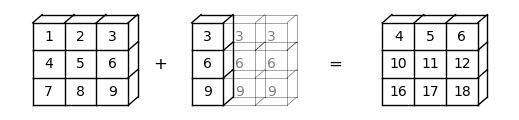

In [59]:
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '6', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '9', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '5', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '6', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '16', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '17', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');


ചില cases-ൽ, രണ്ട് operands-ഉം expand ചെയ്യപ്പെടും.

`a -> (3,)`-ഉം `b -> (3, 1)`-ഉം ഉള്ളപ്പോൾ, `a`, `a -> (3, 3)` ആയി expand ചെയ്യപ്പെടും, `b`, `b -> (3, 3)` ആയും expand ചെയ്യപ്പെടും.

ഈ case-ൽ, element-wise addition ഒരു $3 \times 3$ matrix-ൽ result ചെയ്യും

In [60]:
a = np.array([3, 6, 9])
b = np.array([2, 3, 4])
b.shape = (3, 1)

a + b

array([[ 5,  8, 11],
       [ 6,  9, 12],
       [ 7, 10, 13]])

ഈ broadcasting operation-ന്റെ ഒരു visual representation ഇതാ:

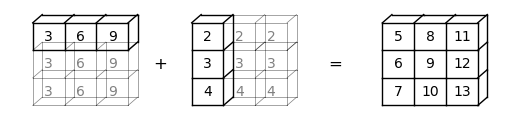

In [61]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (1, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '2', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '3', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '4', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '5', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '11', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '6', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '9', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '10', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '13', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

Broadcasting വളരെ ഉപകാരപ്രദമാണെങ്കിലും, ചിലപ്പോൾ ഇത് confusing ആയി തോന്നാം.

ഉദാഹരണത്തിന്, `a -> (3, 2)`-ഉം `b -> (3,)`-ഉം add ചെയ്യാൻ ശ്രമിക്കാം.

In [62]:
a = np.array(
      [[1, 2],
       [4, 5],
       [7, 8]])
b = np.array([3, 6, 9])

a + b

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

`ValueError`, operands ഒരുമിച്ച് broadcast ചെയ്യാൻ കഴിഞ്ഞില്ല എന്ന് നമ്മോട് പറയുന്നു.


ഈ broadcasting എന്തുകൊണ്ട് execute ചെയ്യാൻ കഴിയില്ല എന്ന് കാണിക്കാൻ ഒരു visual representation ഇതാ:

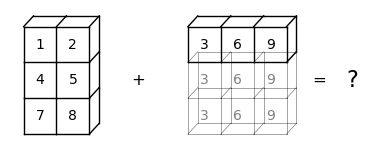

In [63]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(3, 1.3), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 7, 10], '5', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10], '8', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)


ax.text(4.5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10, 7.0, '=', size=12, ha='center', va='center')
ax.text(11, 7.0, '?', size=16, ha='center', va='center');

NumPy-ക്ക് arrays-നെ ഒരേ size-ലേക്ക് expand ചെയ്യാൻ കഴിയില്ല എന്ന് നമുക്ക് കാണാം.

കാരണം, `b`, `b -> (3,)`-ൽ നിന്ന് `b -> (3, 3)` ആയി expand ചെയ്യുമ്പോൾ, NumPy-ക്ക് `b`-യെ `a -> (3, 2)`-യുമായി match ചെയ്യാൻ കഴിയില്ല.

higher dimensions-ലേക്ക് നീങ്ങുമ്പോൾ കാര്യങ്ങൾ കൂടുതൽ tricky ആകുന്നു.

സഹായത്തിന്, നമുക്ക് താഴെപ്പറയുന്ന rules-ന്റെ list ഉപയോഗിക്കാം:

* *Step 1:* രണ്ട് arrays-ന്റെ dimensions match ചെയ്യാത്തപ്പോൾ, existing dimensions-ന്റെ ഇടതുവശത്ത് dimension(s) add ചെയ്ത് fewer dimensions ഉള്ളതിനെ NumPy expand ചെയ്യും.
    - ഉദാഹരണത്തിന്, `a -> (3, 3)`-ഉം `b -> (3,)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്തേക്ക് ഒരു dimension add ചെയ്യും, അതിനാൽ `b -> (1, 3)`;
    - `a -> (2, 2, 2)`-ഉം `b -> (2, 2)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്തേക്ക് ഒരു dimension add ചെയ്യും, അതിനാൽ `b -> (1, 2, 2)`;
    - `a -> (3, 2, 2)`-ഉം `b -> (2,)`-ഉം ആണെങ്കിൽ, broadcasting ഇടതുവശത്തേക്ക് രണ്ട് dimensions add ചെയ്യും, അതിനാൽ `b -> (1, 1, 2)` (ഇത് *Step 1* രണ്ട് പ്രാവശ്യം കടന്നുപോകുന്നതായും കാണാം).


* *Step 2:* രണ്ട് arrays-ന് ഒരേ dimension ഉണ്ടെങ്കിലും വ്യത്യസ്ത shapes ഉള്ളപ്പോൾ, shape index 1 ആയ dimensions expand ചെയ്യാൻ NumPy ശ്രമിക്കും.
    - ഉദാഹരണത്തിന്, `a -> (1, 3)`-ഉം `b -> (3, 1)`-ഉം ആണെങ്കിൽ, broadcasting `a`-യിലും `b`-യിലും shape 1 ഉള്ള dimensions expand ചെയ്യും, അതിനാൽ `a -> (3, 3)`-ഉം `b -> (3, 3)`-ഉം ആകും;
    - `a -> (2, 2, 2)`-ഉം `b -> (1, 2, 2)`-ഉം ആണെങ്കിൽ, broadcasting `b`-ന്റെ ആദ്യ dimension expand ചെയ്യും, അതിനാൽ `b -> (2, 2, 2)`;
    - `a -> (3, 2, 2)`-ഉം `b -> (1, 1, 2)`-ഉം ആണെങ്കിൽ, broadcasting `b`-യെ shape 1 ഉള്ള എല്ലാ dimensions-ലും expand ചെയ്യും, അതിനാൽ `b -> (3, 2, 2)`.

* *Step 3:* Step 1-ഉം 2-ഉം കഴിഞ്ഞ്, രണ്ട് arrays-ഉം ഇപ്പോഴും match ചെയ്യുന്നില്ലെങ്കിൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും. ഉദാഹരണത്തിന്, `a -> (2, 2, 3)`-ഉം `b -> (2, 2)`-ഉം ആണെന്ന് കരുതുക
    - *Step 1* പ്രകാരം, `b`, `b -> (1, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - *Step 2* പ്രകാരം, `b`, `b -> (2, 2, 2)` ആയി expand ചെയ്യപ്പെടും;
    - ആദ്യ രണ്ട് steps-ന് ശേഷം അവ പരസ്പരം match ചെയ്യുന്നില്ല എന്ന് നമുക്ക് കാണാം. അതിനാൽ, ഒരു `ValueError` raise ചെയ്യപ്പെടും



## Mutability and Copying Arrays

NumPy arrays, Python lists പോലെ mutable data types ആണ്.

മറ്റൊരു വിധത്തിൽ പറഞ്ഞാൽ, initialization-ന് ശേഷം അവയുടെ contents memory-യിൽ alter (mutate) ചെയ്യാവുന്നതാണ്.

ഇത് സൗകര്യപ്രദമാണ്, പക്ഷേ, Python-ന്റെ naming, reference model-ഉമായി combine ചെയ്യുമ്പോൾ,
NumPy beginners-ന് mistakes-ലേക്ക് നയിക്കാം.

ഈ section-ൽ നാം ചില key issues review ചെയ്യും.


### Mutability

മുകളിൽ mutability-യുടെ examples നാം ഇതിനകം കണ്ടു.

NumPy array-യുടെ mutation-ന്റെ മറ്റൊരു ഉദാഹരണം ഇതാ

In [64]:
a = np.array([42, 44])
a

array([42, 44])

In [65]:
a[-1] = 0  # Change last element to 0
a

array([42,  0])

Mutability താഴെപ്പറയുന്ന behavior-ലേക്ക് നയിക്കുന്നു (MATLAB programmers-ന് ഇത് shocking ആയേക്കാം...)

In [66]:
rng = np.random.default_rng()
a = rng.standard_normal(3)
a

array([-0.95155504, -0.92233002,  0.65538328])

In [67]:
b = a
b[0] = 0.0
a

array([ 0.        , -0.92233002,  0.65538328])

സംഭവിച്ചത്, `b` change ചെയ്ത് നാം `a`-യെ change ചെയ്തു എന്നതാണ്.

`b` എന്ന name, `a`-യുമായി bind ചെയ്യപ്പെട്ടിരിക്കുന്നു, array-യിലേക്കുള്ള മറ്റൊരു reference മാത്രമായി ഇത് മാറുന്നു
(Python assignment model {doc}`later in the course <python_advanced_features>`-ൽ കൂടുതൽ വിശദമായി describe ചെയ്യപ്പെട്ടിട്ടുണ്ട്).

അതിനാൽ, ആ array-യിൽ changes വരുത്താൻ ഇതിന് equal rights ഉണ്ട്.

ഇത് യഥാർത്ഥത്തിൽ ഏറ്റവും sensible default behavior ആണ്!

copies ഉണ്ടാക്കുന്നതിന് പകരം data-യിലേക്കുള്ള pointers മാത്രമേ നാം pass ചെയ്യുന്നുള്ളൂ എന്നാണ് ഇതിനർത്ഥം.

copies ഉണ്ടാക്കുന്നത് speed-ന്റെയും memory-യുടെയും കാര്യത്തിൽ expensive ആണ്.

### Making Copies

ആവശ്യമുള്ളപ്പോൾ `b`-യെ `a`-യുടെ independent copy ആക്കുന്നത് തീർച്ചയായും സാധ്യമാണ്.

ഇത് `np.copy` ഉപയോഗിച്ച് ചെയ്യാം

In [68]:
a = rng.standard_normal(3)
a

array([-0.86805085, -0.79205297, -0.39914216])

In [69]:
b = np.copy(a)
b

array([-0.86805085, -0.79205297, -0.39914216])

ഇപ്പോൾ `b` ഒരു independent copy ആണ് (ഇതിനെ *deep copy* എന്ന് വിളിക്കുന്നു)

In [70]:
b[:] = 1
b

array([1., 1., 1.])

In [71]:
a

array([-0.86805085, -0.79205297, -0.39914216])

`b`-യിലെ change, `a`-യെ ബാധിച്ചിട്ടില്ല എന്നത് ശ്രദ്ധിക്കുക.




## Additional Features

NumPy-യുടെ മറ്റ് ചില ഉപകാരപ്രദമായ features നോക്കാം.


### Universal Functions

```{index} single: NumPy; Vectorized Functions
```

NumPy, `log`, `exp`, `sin` മുതലായ standard functions-ന്റെ versions നൽകുന്നു, ഇവ arrays-ൽ *element-wise* ആയി act ചെയ്യുന്നു

In [72]:
z = np.array([1, 2, 3])
np.sin(z)

array([0.84147098, 0.90929743, 0.14112001])

ഇത് explicit element-by-element loops-ന്റെ ആവശ്യകത ഇല്ലാതാക്കുന്നു, ഉദാഹരണത്തിന്

In [73]:
n = len(z)
y = np.empty(n)
for i in range(n):
    y[i] = np.sin(z[i])

arrays-ൽ element-wise ആയി act ചെയ്യുന്നതിനാൽ, ഈ functions-നെ ചിലപ്പോൾ **vectorized functions** എന്ന് വിളിക്കുന്നു.

NumPy-speak-ൽ, അവയെ **ufuncs**, അല്ലെങ്കിൽ **universal functions** എന്നും വിളിക്കുന്നു.

മുകളിൽ നാം കണ്ടതുപോലെ, usual arithmetic operations (`+`, `*`, etc.)-ഉം
element-wise ആയി പ്രവർത്തിക്കുന്നു, ഇവയെ ufuncs-ഉമായി combine ചെയ്യുന്നത് fast element-wise functions-ന്റെ വളരെ വലിയൊരു set നൽകുന്നു.

In [74]:
z

array([1, 2, 3])

In [75]:
(1 / np.sqrt(2 * np.pi)) * np.exp(- 0.5 * z**2)

array([0.24197072, 0.05399097, 0.00443185])

എല്ലാ user-defined functions-ഉം element-wise ആയി act ചെയ്യില്ല.

ഉദാഹരണത്തിന്, താഴെ define ചെയ്ത `f` function-ന് ഒരു NumPy array pass ചെയ്യുന്നത് ഒരു `ValueError`-ന് കാരണമാകുന്നു

In [76]:
def f(x):
    return 1 if x > 0 else 0

NumPy function `np.where`, ഒരു vectorized alternative നൽകുന്നു:

In [77]:
x = rng.standard_normal(4)
x

array([-0.93935317,  1.96917983, -1.84740532,  0.53304951])

In [78]:
np.where(x > 0, 1, 0)  # Insert 1 if x > 0 true, otherwise 0

array([0, 1, 0, 1])

ഒരു given function vectorize ചെയ്യാൻ `np.vectorize`-ഉം ഉപയോഗിക്കാം

In [79]:
f = np.vectorize(f)
f(x)                # Passing the same vector x as in the previous example

array([0, 1, 0, 1])

എന്നിരുന്നാലും, ഈ approach, ഒരു കൂടുതൽ carefully crafted vectorized function-ന്റെ speed ലഭിക്കില്ല എപ്പോഴും.

(പിന്നീട് JAX-ന്, `np.vectorize`-ന്റെ ഒരു powerful version ഉണ്ടെന്ന് നാം കാണും, ഇത് highly efficient code generate ചെയ്യാൻ കഴിയുന്നതും സാധാരണയായി ചെയ്യുന്നതും ആണ്.)


### Comparisons

```{index} single: NumPy; Comparisons
```

Rule ആയി, arrays-ൽ comparisons element-wise ആയി ചെയ്യപ്പെടുന്നു

In [80]:
z = np.array([2, 3])
y = np.array([2, 3])
z == y

array([ True,  True])

In [81]:
y[0] = 5
z == y

array([False,  True])

In [82]:
z != y

array([ True, False])

`>`, `<`, `>=`, `<=`-ന്റെ situation സമാനമാണ്.

Scalars-നെതിരെയും നമുക്ക് comparisons ചെയ്യാം

In [83]:
z = np.linspace(0, 10, 5)
z

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [84]:
z > 3

array([False, False,  True,  True,  True])

*conditional extraction*-ന് ഇത് പ്രത്യേകിച്ച് ഉപകാരപ്രദമാണ്

In [85]:
b = z > 3
b

array([False, False,  True,  True,  True])

In [86]:
z[b]

array([ 5. ,  7.5, 10. ])

തീർച്ചയായും നമുക്ക് ഇത് ഒരു step-ൽ perform ചെയ്യാം---സാധാരണയായി നാം ചെയ്യുകയും ചെയ്യുന്നു

In [87]:
z[z > 3]

array([ 5. ,  7.5, 10. ])

### Sub-packages

NumPy, അതിന്റെ sub-packages വഴി scientific programming-മായി ബന്ധപ്പെട്ട additional functionality
നൽകുന്നു.

NumPy-യുടെ 
[random `Generator`](https://numpy.org/doc/stable/reference/random/generator.html#random-generator) ഉപയോഗിച്ച് random variables generate ചെയ്യുന്നത് നാം ഇതിനകം കണ്ടു.

In [88]:
z = rng.standard_normal(10000)  # Generate standard normals
y = rng.binomial(10, 0.5, size=1000)    # 1,000 draws from Bin(10, 0.5)
y.mean()

np.float64(5.018)

സാധാരണയായി ഉപയോഗിക്കുന്ന മറ്റൊരു subpackage np.linalg ആണ്

In [89]:
A = np.array([[1, 2], [3, 4]])

np.linalg.det(A)           # Compute the determinant

np.float64(-2.0000000000000004)

In [90]:
np.linalg.inv(A)           # Compute the inverse

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

```{index} single: SciPy
```

```{index} single: Python; SciPy
```

ഈ functionality-യുടെ ഭൂരിഭാഗവും [SciPy](https://scipy.org/)-ലും ലഭ്യമാണ്, ഇത് NumPy-ന്റെ മുകളിൽ built ചെയ്ത modules-ന്റെ ഒരു collection ആണ്.

SciPy versions നാം {doc}`soon <scipy>` കൂടുതൽ വിശദമായി cover ചെയ്യും.

NumPy-ൽ ലഭ്യമായതിന്റെ ഒരു comprehensive list-ന്, [this documentation](https://numpy.org/doc/stable/reference/routines.html) കാണുക.


### Implicit Multithreading 

[Previously](need_for_speed) നാം multithreading വഴി parallelization-ന്റെ concept discuss ചെയ്തു.

NumPy, അതിന്റെ compiled code-ന്റെ ഭൂരിഭാഗത്തിലും multithreading implement ചെയ്യാൻ ശ്രമിക്കുന്നു.

ഇത് action-ൽ കാണാൻ ഒരു example നോക്കാം.

randomly generate ചെയ്ത matrices-ന്റെ ഒരു large number-ന്റെ eigenvalues, അടുത്ത code
compute ചെയ്യുന്നു.

ഇത് run ചെയ്യാൻ കുറച്ച് seconds എടുക്കുന്നു.

In [91]:
n = 20
m = 1000
for i in range(n):
    X = rng.standard_normal((m, m))
    λ = np.linalg.eigvals(X)

ഇപ്പോൾ, ഈ code run ചെയ്യുമ്പോൾ നമ്മുടെ machine-ലെ htop system monitor-ന്റെ output
നോക്കാം:

```{figure} /_static/lecture_specific/parallelization/htop_parallel_npmat.png
:scale: 80
```

8 CPUs-ൽ 4-ഉം full speed-ൽ run ചെയ്യുന്നത് നമുക്ക് കാണാം.

NumPy-യുടെ `eigvals` routine, tasks neatly split ചെയ്ത് different threads-ലേക്ക്
distribute ചെയ്യുന്നതിനാലാണ് ഇത്.





## Exercises


```{exercise-start}
:label: np_ex1
```

താഴെപ്പറയുന്ന polynomial expression പരിഗണിക്കുക

```{math}
:label: np_polynom

p(x) = a_0 + a_1 x + a_2 x^2 + \cdots a_N x^N = \sum_{n=0}^N a_n x^n
```

{ref}`Earlier <pyess_ex2>`, efficiency പരിഗണിക്കാതെ {eq}`np_polynom` evaluate ചെയ്യാൻ നിങ്ങൾ ഒരു simple function `p(x, coeff)` എഴുതി.

ഇപ്പോൾ ഇതേ job ചെയ്യുന്ന ഒരു new function എഴുതുക, പക്ഷേ അതിന്റെ computations-ന് ഏത് തരത്തിലുള്ള Python loop-നും പകരം NumPy arrays-ഉം array operations-ഉം ഉപയോഗിക്കണം.

(ഈ functionality ഇതിനകം `np.poly1d` ആയി implement ചെയ്യപ്പെട്ടിട്ടുണ്ട്, പക്ഷേ exercise-ന്റെ ആവശ്യത്തിന് ഈ class ഉപയോഗിക്കരുത്)

```{hint}
:class: dropdown
`np.cumprod()` ഉപയോഗിക്കുക
```
```{exercise-end}
```

```{solution-start} np_ex1
:class: dropdown
```

ഈ code job ചെയ്യുന്നു

In [92]:
def p(x, coef):
    X = np.ones_like(coef)
    X[1:] = x
    y = np.cumprod(X)   # y = [1, x, x**2,...]
    return coef @ y

നമുക്ക് ഇത് test ചെയ്യാം

In [93]:
x = 2
coef = np.linspace(2, 4, 3)
print(coef)
print(p(x, coef))
# For comparison
q = np.poly1d(np.flip(coef))
print(q(x))

[2. 3. 4.]
24.0
24.0


```{solution-end}
```


```{exercise-start}
:label: np_ex2
```

`q`, `q.sum() == 1` ഉള്ള `n` length-ന്റെ ഒരു NumPy array ആണെന്ന് കരുതുക.

`q`, ഒരു [probability mass function](https://en.wikipedia.org/wiki/Probability_mass_function) represent ചെയ്യുന്നു എന്ന് കരുതുക.

$\mathbb P\{x = i\} = q_i$ ആയ ഒരു discrete random variable $x$ generate ചെയ്യാൻ നാം ആഗ്രഹിക്കുന്നു.

മറ്റൊരു വിധത്തിൽ പറഞ്ഞാൽ, `x`, `range(len(q))`-ൽ values എടുക്കുന്നു, `x = i`, `q[i]` probability-യിൽ ആണ്.

standard (inverse transform) algorithm താഴെപ്പറയുന്നത് ആണ്:

* unit interval $[0, 1]$-നെ $n$ subintervals $I_0, I_1, \ldots, I_{n-1}$ ആയി divide ചെയ്യുക, അതായത് $I_i$-യുടെ length $q_i$ ആയിരിക്കണം.
* $[0, 1]$-ൽ ഒരു uniform random variable $U$ draw ചെയ്ത്, $U \in I_i$ ആയ $i$ return ചെയ്യുക.

$i$ draw ചെയ്യാനുള്ള probability, $I_i$-യുടെ length ആണ്, ഇത് $q_i$-ന് equal ആണ്.

നമുക്ക് algorithm താഴെപ്പറയുന്ന വിധം implement ചെയ്യാം

In [94]:
from random import uniform

def sample(q):
    a = 0.0
    U = uniform(0, 1)
    for i in range(len(q)):
        if a < U <= a + q[i]:
            return i
        a = a + q[i]

ഇത് എങ്ങനെ പ്രവർത്തിക്കുന്നു എന്ന് കാണാൻ കഴിയുന്നില്ലെങ്കിൽ, `q = [0.25, 0.75]` പോലുള്ള ഒരു simple example-ന്റെ flow ചിന്തിച്ച് നോക്കുക.
paper-ൽ intervals sketch ചെയ്യുന്നത് സഹായകമാണ്.

explicit loops ഒഴിവാക്കി, NumPy ഉപയോഗിച്ച് ഇത് speed up ചെയ്യുകയാണ് നിങ്ങളുടെ exercise

```{hint}
:class: dropdown

`np.searchsorted`-ഉം `np.cumsum`-ഉം ഉപയോഗിക്കുക

```

നിങ്ങൾക്ക് കഴിയുമെങ്കിൽ, `DiscreteRV` എന്ന ഒരു class ആയി functionality implement ചെയ്യുക, ഇവിടെ

* class-ന്റെ ഒരു instance-ന്റെ data, probabilities-ന്റെ vector `q` ആണ്
* class-ന് ഒരു `draw()` method ഉണ്ട്, ഇത് മുകളിൽ describe ചെയ്ത algorithm പ്രകാരം ഒരു draw return ചെയ്യുന്നു

നിങ്ങൾക്ക് കഴിയുമെങ്കിൽ, `draw(k)`, `q`-ൽ നിന്ന് `k` draws return ചെയ്യുന്ന വിധം method എഴുതുക.

```{exercise-end}
```

```{solution-start} np_ex2
:class: dropdown
```

ഇതാ ഒരു solution-ലേക്കുള്ള നമ്മുടെ first pass:

In [95]:
from numpy import cumsum

class DiscreteRV:
    """
    Generates an array of draws from a discrete random variable with vector of
    probabilities given by q.
    """

    def __init__(self, q, seed=None):
        """
        The argument q is a NumPy array, or array like, nonnegative and sums
        to 1
        """
        self.q = q
        self.Q = cumsum(q)
        self.rng = np.random.default_rng(seed)

    def draw(self, k=1):
        """
        Returns k draws from q. For each such draw, the value i is returned
        with probability q[i].
        """
        return self.Q.searchsorted(self.rng.uniform(0, 1, size=k))

Logic obvious അല്ല, പക്ഷേ നിങ്ങൾ time എടുത്ത് slowly read ചെയ്താൽ,
നിങ്ങൾക്ക് ഇത് understand ചെയ്യാൻ കഴിയും.

എന്നിരുന്നാലും, ഇവിടെ ഒരു problem ഉണ്ട്.

`discreteRV`-യുടെ ഒരു instance create ചെയ്ത ശേഷം `q` alter ചെയ്യപ്പെട്ടു എന്ന് കരുതുക, ഉദാഹരണത്തിന്

In [96]:
q = (0.1, 0.9)
d = DiscreteRV(q)
d.q = (0.5, 0.5)

Problem, `Q` accordingly change ആകുന്നില്ല, `draw` method-ൽ ഉപയോഗിക്കുന്ന data
`Q` ആണ് എന്നതാണ്.

ഇത് deal ചെയ്യാൻ, ഒരു option, draw method call ചെയ്യുന്ന ഓരോ പ്രാവശ്യവും `Q` compute
ചെയ്യുക എന്നതാണ്.

പക്ഷേ ഇത്, `Q` once-off compute ചെയ്യുന്നതിനെ അപേക്ഷിച്ച് inefficient ആണ്.

Descriptors ഉപയോഗിക്കുക എന്നതാണ് ഒരു മികച്ച option.

നാം ആഗ്രഹിക്കുന്ന വിധം behave ചെയ്യുന്ന descriptors ഉപയോഗിച്ചുള്ള [quantecon
library](https://github.com/QuantEcon/QuantEcon.py/tree/main/quantecon)-ൽ നിന്നുള്ള ഒരു solution
[ഇവിടെ](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/discrete_rv.py) കാണാം.

```{solution-end}
```


```{exercise}
:label: np_ex3

empirical cumulative distribution function-നെക്കുറിച്ചുള്ള നമ്മുടെ {ref}`earlier discussion <oop_ex1>` ഓർക്കുക.

നിങ്ങളുടെ task,

1. NumPy ഉപയോഗിച്ച് `__call__` method കൂടുതൽ efficient ആക്കുക.
1. $[a, b]$-ൽ ECDF plot ചെയ്യുന്ന ഒരു method add ചെയ്യുക, ഇവിടെ $a$-ഉം $b$-ഉം method parameters ആണ്.
```

```{solution-start} np_ex3
:class: dropdown
```

താഴെ ഒരു example solution നൽകിയിരിക്കുന്നു.

സത്തയിൽ, QuantEcon-ൽ നിന്നുള്ള [this code](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/ecdf.py)
നാം എടുത്ത് ഒരു plot method add ചെയ്തിരിക്കുന്നു

In [97]:
"""
Modifies ecdf.py from QuantEcon to add in a plot method

"""

class ECDF:
    """
    One-dimensional empirical distribution function given a vector of
    observations.

    Parameters
    ----------
    observations : array_like
        An array of observations

    Attributes
    ----------
    observations : array_like
        An array of observations

    """

    def __init__(self, observations):
        self.observations = np.asarray(observations)

    def __call__(self, x):
        """
        Evaluates the ecdf at x

        Parameters
        ----------
        x : scalar(float)
            The x at which the ecdf is evaluated

        Returns
        -------
        scalar(float)
            Fraction of the sample less than x

        """
        return np.mean(self.observations <= x)

    def plot(self, ax, a=None, b=None):
        """
        Plot the ecdf on the interval [a, b].

        Parameters
        ----------
        a : scalar(float), optional(default=None)
            Lower endpoint of the plot interval
        b : scalar(float), optional(default=None)
            Upper endpoint of the plot interval

        """

        # === choose reasonable interval if [a, b] not specified === #
        if a is None:
            a = self.observations.min() - self.observations.std()
        if b is None:
            b = self.observations.max() + self.observations.std()

        # === generate plot === #
        x_vals = np.linspace(a, b, num=100)
        f = np.vectorize(self.__call__)
        ax.plot(x_vals, f(x_vals))
        plt.show()

ഇതാ usage-ന്റെ ഒരു example

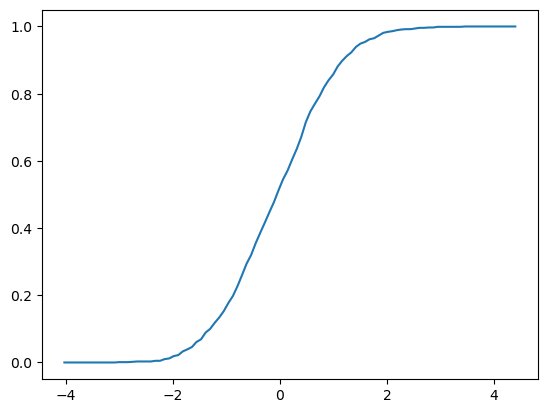

In [98]:
fig, ax = plt.subplots()
rng = np.random.default_rng()
X = rng.standard_normal(1000)
F = ECDF(X)
F.plot(ax)

```{solution-end}
```


```{exercise-start}
:label: np_ex4
```

Numpy-ലെ [broadcasting](broadcasting), `for` loops ഉപയോഗിക്കാതെ different number of dimensions ഉള്ള arrays-ൽ element-wise operations conduct ചെയ്യാൻ നമ്മെ സഹായിക്കുമെന്ന് ഓർക്കുക.

ഈ exercise-ൽ, താഴെപ്പറയുന്ന broadcasting operations-ന്റെ result replicate ചെയ്യാൻ `for` loops ഉപയോഗിച്ച് ശ്രമിക്കുക.

**Part1**: `for` loops ഉപയോഗിച്ച് ഈ simple example replicate ചെയ്യാൻ ശ്രമിക്കുക, താഴെയുള്ള broadcasting operation-ഉമായി നിങ്ങളുടെ results compare ചെയ്യുക.

In [99]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)
A = x / y

ഇതാ output

In [100]:
print(A)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


**Part2**: താഴെപ്പറയുന്ന broadcasting operation-ന്റെ result replicate ചെയ്യാൻ നീങ്ങുക. അതേസമയം, broadcasting-ന്റെയും നിങ്ങൾ implement ചെയ്യുന്ന `for` loop-ന്റെയും speeds compare ചെയ്യുക.

exercise-ന്റെ ഈ part-ന്, execution time ചെയ്യാൻ `quantecon` library-യിലെ `tic`/`toc` functions ഉപയോഗിക്കാം.

ഈ library install ചെയ്തിട്ടുണ്ട് എന്ന് ഉറപ്പുവരുത്താം.

In [101]:
!pip install quantecon

ഇപ്പോൾ നമുക്ക് quantecon package import ചെയ്യാം.

In [102]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("Broadcasting operation"):
    B = x / y

Broadcasting operation: 0.0093 seconds elapsed


ഇതാ output

In [103]:
print(B)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

```{exercise-end}
```


```{solution-start} np_ex4
:class: dropdown
```

**Part 1 Solution**

In [104]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)

C = np.empty_like(x)
n = len(x)
for i in range(n):
    for j in range(n):
        C[i, j] = x[i, j] / y[j]

നിങ്ങളുടെ answer check ചെയ്യാൻ results compare ചെയ്യുക

In [105]:
print(C)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


നിങ്ങളുടെ answer check ചെയ്യാൻ `array_equal()`-ഉം ഉപയോഗിക്കാം

In [106]:
print(np.array_equal(A, C))

True


**Part 2 Solution**

In [107]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("For loop operation"):
    D = np.empty_like(x)
    d1, d2, d3 = x.shape
    for i in range(d1):
        for j in range(d2):
            for k in range(d3):
                D[i, j, k] = x[i, j, k] / y[k]

For loop operation: 3.7468 seconds elapsed


`for` loop, broadcasting operation-നെക്കാൾ വളരെയധികം time എടുക്കുന്നു എന്നത് ശ്രദ്ധിക്കുക.

നിങ്ങളുടെ answer check ചെയ്യാൻ results compare ചെയ്യുക

In [108]:
print(D)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

In [109]:
print(np.array_equal(B, D))

True


```{solution-end}
```